# Banded Ridge Regression - Small Playground

In [1]:
from himalaya.ridge import BandedRidgeCV
import numpy as np
import torch

import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
T = 5000

X_1 = np.linspace(-1, 1, T) + np.random.randn(T) * 0.1
X_2 = np.linspace(1, -1, T) + np.random.randn(T) * 0.1
Y = np.linspace(-1, 1, T) + np.random.randn(T) * 0.1

In [3]:
t = np.linspace(0, 1, T)

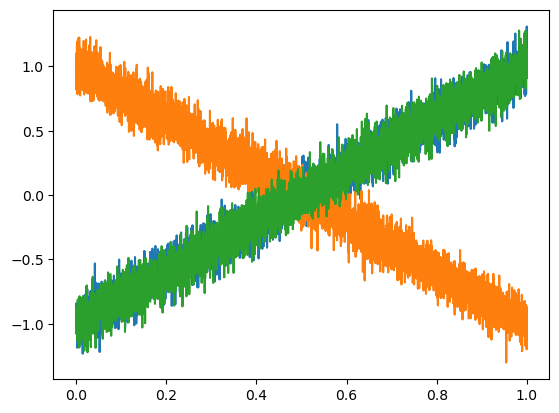

In [4]:
plt.plot(t, X_1, t, X_2, t, Y)

In [5]:
X_1 = np.expand_dims(X_1, axis=1)
X_2 = np.expand_dims(X_2, axis=1)
Y = np.expand_dims(Y, axis=1)

In [6]:
X = [X_1, X_2]

model = BandedRidgeCV(groups="input", cv=50)
model.fit(X, Y)

[........................................] 100% | 3.78 sec | 100 random sampling with cv | 
💡 Hello world from himalaya/ridge/_sklearn_api.py !


GroupRidgeCV(cv=50, groups='input')

In [7]:
best_alphas_ret_ = model.best_alphas_ret_
best_alphas_ = model.best_alphas_
best_gammas_ = model.best_gammas_

In [9]:
print(best_alphas_)
print(best_alphas_ret_)
print(best_gammas_)

[1.]
[1.]
[[0.50606538]
 [0.49393462]]


In [ ]:
hparams = {
    "alphas": model.best_alphas_,
    "deltas": model.deltas_,
    "weights": model.coef_,
}

In [10]:
print(hparams)

{'alphas': array([1.]), 'deltas': array([[-0.6810894 ],
       [-0.70535213]]), 'weights': array([[ 0.49887508],
       [-0.49388887]])}


In [11]:
X_1_test = np.expand_dims(np.linspace(-1, 1, T) + np.random.randn(T) * 0.1, axis=1)
X_2_test = np.expand_dims(np.linspace(1, -1, T) + np.random.randn(T) * 0.1, axis=1)

Y_pred = model.predict([X_1_test, X_2_test])

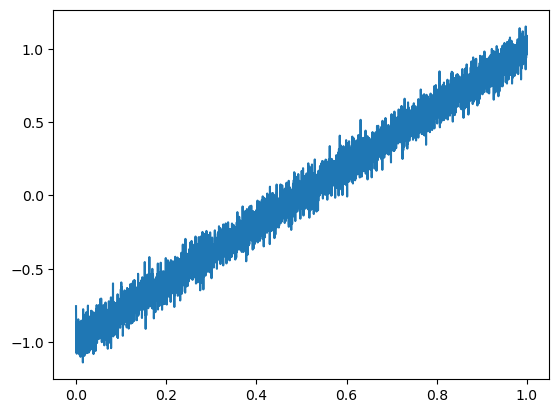

In [12]:
plt.plot(t, Y_pred)

## Try WeightedKernelRidge

In [13]:
from himalaya.kernel_ridge import WeightedKernelRidge

In [14]:
wkr_model = WeightedKernelRidge(
    alpha=hparams["alphas"], deltas=hparams["deltas"], kernels=["precomputed"]
)

In [15]:
print(X)
wkr_model.fit(X, Y)

[array([[-0.95032858],
       [-1.01342635],
       [-0.93443099],
       ...,
       [ 1.31049086],
       [ 1.08040354],
       [ 0.91519344]]), array([[ 0.95762403],
       [ 0.95425851],
       [ 0.81963552],
       ...,
       [-1.06973151],
       [-0.95002336],
       [-0.93556115]])]


ValueError: Found array with ndim 3, expected 2. Reshape your data or change the input.

### Example from himalaya

In [ ]:
from himalaya.kernel_ridge import WeightedKernelRidge
from himalaya.kernel_ridge import ColumnKernelizer
from himalaya.kernel_ridge import Kernelizer
from sklearn.pipeline import make_pipeline

In [ ]:
# create a dataset
import numpy as np

n_samples, n_features, n_targets = 10, 5, 3
X = np.random.randn(n_samples, n_features)
Y = np.random.randn(n_samples, n_targets)

In [ ]:
# Kernelize separately the first three columns and the last two
# columns, creating two kernels of shape (n_samples, n_samples).
ck = ColumnKernelizer(
    [
        ("kernel_1", Kernelizer(kernel="linear"), [0, 1, 2]),
        ("kernel_2", Kernelizer(kernel="polynomial"), slice(3, 5)),
    ]
)

In [ ]:
# A model with precomputed kernels, as output by ColumnKernelizer
model = WeightedKernelRidge(kernels="precomputed")
pipe = make_pipeline(ck, model)
pipe.fit(X, Y)

Pipeline(steps=[('columnkernelizer',
                 ColumnKernelizer(transformers=[('kernel_1', Kernelizer(),
                                                 [0, 1, 2]),
                                                ('kernel_2',
                                                 Kernelizer(kernel='polynomial'),
                                                 slice(3, 5, None))])),
                ('weightedkernelridge',
                 WeightedKernelRidge(kernels='precomputed'))])

In [ ]:
print(type(X))
print(X.shape)
print(X)

<class 'numpy.ndarray'>
(10, 5)
[[-0.59975424  0.29729163  0.23471773 -0.41702218 -0.26941062]
 [-1.45360645  1.40276431  0.6874564   0.65144805 -1.59503222]
 [-0.59548999 -0.33454603 -1.93106149  0.8899501   1.45388449]
 [ 2.06193496 -1.04588383  0.1173235   1.32281827 -0.25361848]
 [-0.56698791 -1.86601767  1.13262246 -0.01926076 -0.72934186]
 [ 0.28385729  0.15300537  0.1682591  -0.21709806  1.62235816]
 [-0.13365973  1.61932208  0.56411693  0.35117014 -0.11327475]
 [ 0.97395669  0.11299177 -0.93213122 -0.96549219  0.42248462]
 [-0.90737889 -0.06223106  1.05718454  0.30397018 -0.72213487]
 [ 1.40998751  0.54787524  1.01779299 -2.26755834  0.33085288]]
